Import and Loading the Data

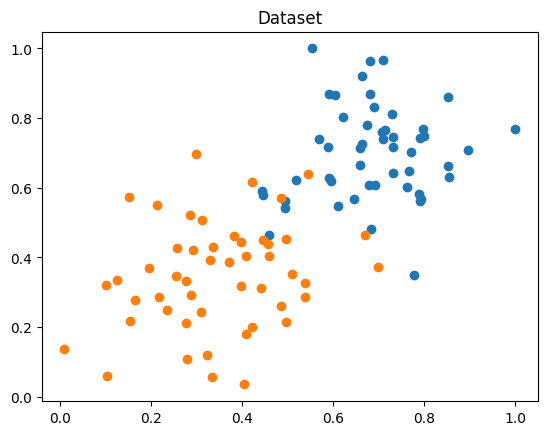

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("data.csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Plot data
plt.scatter(X[y==0][:,0], X[y==0][:,1])
plt.scatter(X[y==1][:,0], X[y==1][:,1])
plt.title("Dataset")
plt.show()

In [ ]:
Heuristic Perceptron

In [2]:
def perceptron_heuristic(X, y, lr=0.1, epochs=50):
    weights = np.random.randn(X.shape[1])
    bias = np.random.randn()
    
    lines = []

    for epoch in range(epochs):
        for i in range(len(X)):
            z = np.dot(weights, X[i]) + bias
            y_hat = 1 if z >= 0 else 0
            
            error = y[i] - y_hat
            
            weights += lr * error * X[i]
            bias += lr * error
        
        lines.append((weights.copy(), bias))

    return weights, bias, lines

In [3]:
def plot_lines(X, y, lines, title):
    plt.scatter(X[y==0][:,0], X[y==0][:,1])
    plt.scatter(X[y==1][:,0], X[y==1][:,1])
    
    x_vals = np.linspace(0,1,100)

    # initial line (RED)
    w, b = lines[0]
    y_vals = -(w[0]*x_vals + b)/w[1]
    plt.plot(x_vals, y_vals, 'r')

    # intermediate (GREEN dashed)
    for w,b in lines[1:-1]:
        y_vals = -(w[0]*x_vals + b)/w[1]
        plt.plot(x_vals, y_vals, 'g--', alpha=0.3)

    # final (BLACK)
    w, b = lines[-1]
    y_vals = -(w[0]*x_vals + b)/w[1]
    plt.plot(x_vals, y_vals, 'k', linewidth=2)

    plt.title(title)
    plt.show()

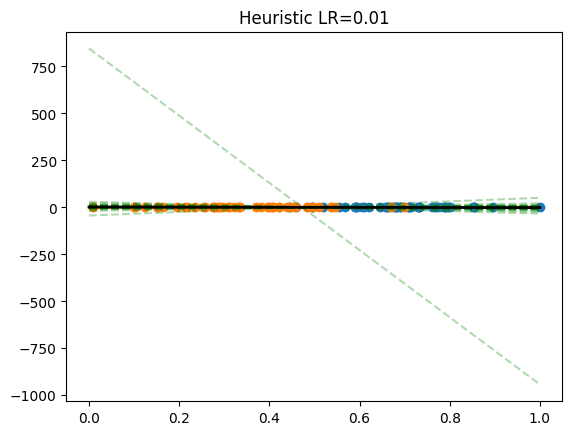

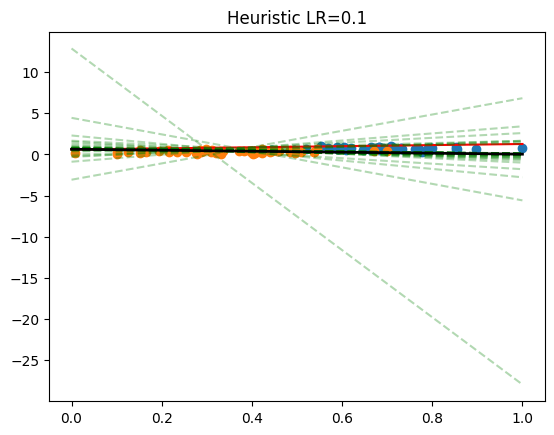

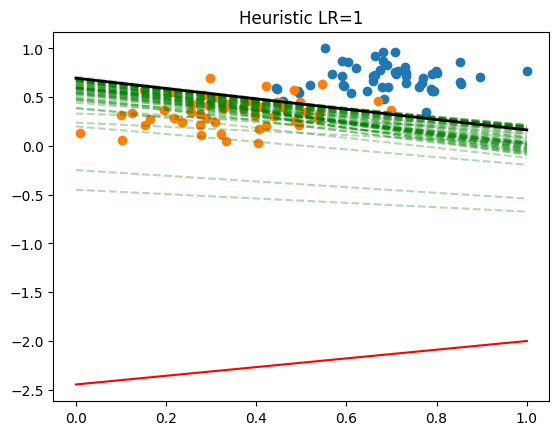

In [4]:
for lr in [0.01, 0.1, 1]:
    w, b, lines = perceptron_heuristic(X, y, lr=lr, epochs=65)
    plot_lines(X, y, lines, f"Heuristic LR={lr}")

Part 2 - Gradient Descent

In [5]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def log_loss(y, y_hat):
    return -np.mean(y*np.log(y_hat+1e-9) + (1-y)*np.log(1-y_hat+1e-9))

In [6]:
def perceptron_gd(X, y, lr=0.1, epochs=100):
    weights = np.random.randn(X.shape[1])
    bias = np.random.randn()
    
    losses = []
    lines = []

    for epoch in range(epochs):
        z = np.dot(X, weights) + bias
        y_hat = sigmoid(z)

        loss = log_loss(y, y_hat)
        
        dw = np.dot(X.T, (y_hat - y)) / len(y)
        db = np.mean(y_hat - y)

        weights -= lr * dw
        bias -= lr * db

        if epoch % 10 == 0:
            losses.append(loss)
            lines.append((weights.copy(), bias))

    return weights, bias, losses, lines

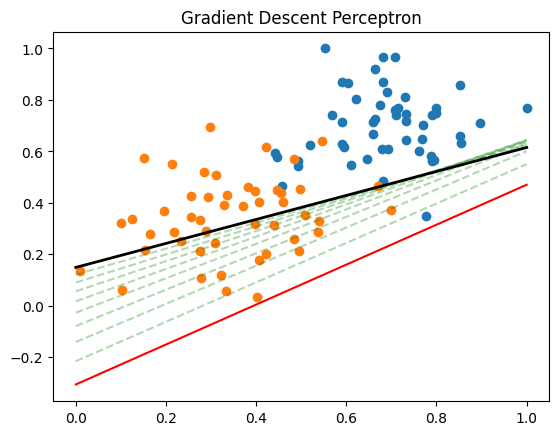

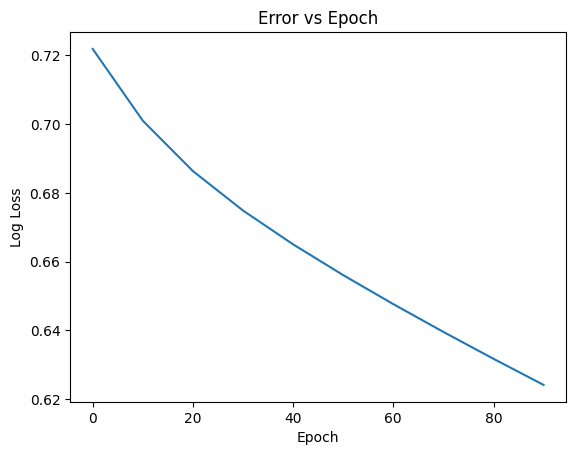

In [7]:
w, b, losses, lines = perceptron_gd(X, y, lr=0.1, epochs=100)

plot_lines(X, y, lines, "Gradient Descent Perceptron")

# Error plot
plt.plot(range(0,100,10), losses)
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Error vs Epoch")
plt.show()